# Trabalho Computacional 1: Equação do Calor unidimensional em regime estacionário
## PPG-Biometria
### Disciplina: Matemática Aplicada 
### Professor: Fernando Luiz Pio dos Santos
### Aluno: Vitor Eduardo Girotto Barelli

### Objetivo

Resolver numericamente a equação do calor unidimensional em regime estacionário por meio do Método das Diferenças Finitas, obter a solução analítica e comparar ambas graficamente.

---

### Problema considerado

No regime estacionário, a equação do calor unidimensional é dada por:

\[
\frac{d^2T}{dx^2}=0
\]

em uma barra de comprimento \(L\), sujeita às condições de contorno:

\[
T(0)=100
\]

\[
T(L)=20
\]

Neste exemplo, será adotado \(L=1\).

---

### Solução analítica

A equação diferencial é:

\[
\frac{d^2T}{dx^2}=0
\]

Integrando duas vezes, obtemos:

\[
T(x)=C_1x+C_2
\]

Aplicando as condições de contorno:

- \(T(0)=100 \Rightarrow C_2=100\)
- \(T(1)=20 \Rightarrow C_1+100=20 \Rightarrow C_1=-80\)

Logo, a solução analítica é:

\[
T(x)=100-80x
\]

---

### Discretização por Diferenças Finitas

A derivada segunda é aproximada por diferenças centrais:

\[
\frac{d^2T}{dx^2}\approx \frac{T_{i+1}-2T_i+T_{i-1}}{\Delta x^2}
\]

Substituindo na equação:

\[
\frac{T_{i+1}-2T_i+T_{i-1}}{\Delta x^2}=0
\]

Multiplicando por \(\Delta x^2\):

\[
T_{i+1}-2T_i+T_{i-1}=0
\]

Essa equação será aplicada em todos os pontos internos da malha, gerando um sistema linear.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Definição dos parâmetros do problema
# Comprimento da barra
L = 1.0

# Condições de contorno
T_esq = 100.0
T_dir = 20.0

# Número de pontos da malha
Nx = 11

# Passo espacial
dx = L / (Nx - 1)

print(f"Número de pontos = {Nx}")
print(f"dx = {dx}")

Número de pontos = 11
dx = 0.1


In [3]:
## Construção da malha espacial
x = np.linspace(0, L, Nx)
x

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

### Montagem do sistema linear

Para os pontos internos da malha, aplica-se:

\[
T_{i-1}-2T_i+T_{i+1}=0
\]

Como os valores nas extremidades são conhecidos pelas condições de contorno, o sistema linear será montado apenas para os pontos internos.

In [4]:
# Número de pontos internos
Nint = Nx - 2

# Matriz dos coeficientes
A = np.zeros((Nint, Nint))

# Vetor do lado direito
b = np.zeros(Nint)

for i in range(Nint):
    A[i, i] = -2
    
    if i > 0:
        A[i, i - 1] = 1
        
    if i < Nint - 1:
        A[i, i + 1] = 1

# Inclusão das condições de contorno no vetor b
b[0] = -T_esq
b[-1] = -T_dir

print("Matriz A:")
print(A)

print("\nVetor b:")
print(b)

Matriz A:
[[-2.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  1. -2.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  1. -2.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -2.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. -2.  1.]
 [ 0.  0.  0.  0.  0.  0.  0.  1. -2.]]

Vetor b:
[-100.    0.    0.    0.    0.    0.    0.    0.  -20.]


In [5]:
# Resolvendo o sistema linear para os pontos internos
T_interno = np.linalg.solve(A, b)

# Montando o vetor completo da solução numérica
T_num = np.zeros(Nx)
T_num[0] = T_esq
T_num[-1] = T_dir
T_num[1:-1] = T_interno

print("Solução numérica:")
print(T_num)

Solução numérica:
[100.  92.  84.  76.  68.  60.  52.  44.  36.  28.  20.]


In [6]:
## Solução analítica
T_analitica = 100 - 80*x

print("Solução analítica:")
print(T_analitica)

Solução analítica:
[100.  92.  84.  76.  68.  60.  52.  44.  36.  28.  20.]


In [7]:
## Erro entre a solução numérica e a solução analítica
erro = np.abs(T_num - T_analitica)
erro_max = np.max(erro)

print("Erro absoluto em cada ponto:")
print(erro)

print(f"\nErro máximo = {erro_max:.6e}")

Erro absoluto em cada ponto:
[0.00000000e+00 0.00000000e+00 1.42108547e-14 1.42108547e-14
 0.00000000e+00 0.00000000e+00 1.42108547e-14 7.10542736e-15
 0.00000000e+00 0.00000000e+00 0.00000000e+00]

Erro máximo = 1.421085e-14


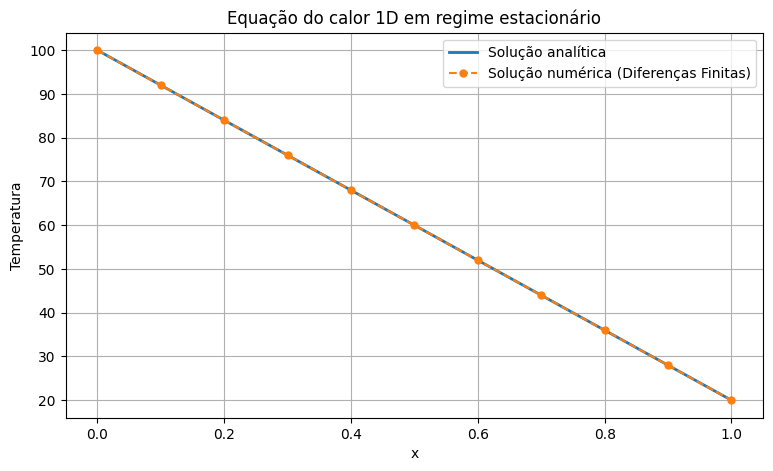

In [8]:
## Comparação gráfica entre as soluções
plt.figure(figsize=(9,5))
plt.plot(x, T_analitica, label='Solução analítica', linewidth=2)
plt.plot(x, T_num, 'o--', label='Solução numérica (Diferenças Finitas)', markersize=5)
plt.xlabel('x')
plt.ylabel('Temperatura')
plt.title('Equação do calor 1D em regime estacionário')
plt.grid(True)
plt.legend()
plt.show()

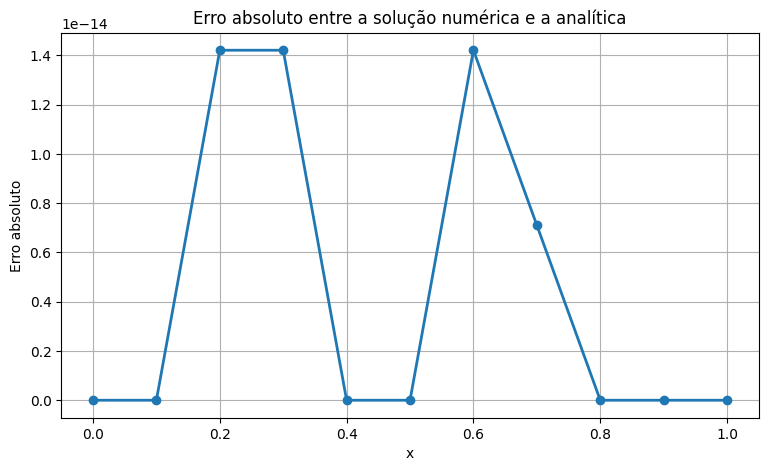

In [9]:
## Gráfico do erro absoluto
plt.figure(figsize=(9,5))
plt.plot(x, erro, 'o-', linewidth=2)
plt.xlabel('x')
plt.ylabel('Erro absoluto')
plt.title('Erro absoluto entre a solução numérica e a analítica')
plt.grid(True)
plt.show()

### Conclusão

A equação do calor unidimensional em regime estacionário foi resolvida numericamente por meio do Método das Diferenças Finitas. A derivada segunda foi aproximada por diferenças centrais, o que levou a um sistema linear para os pontos internos da malha.

A solução analítica do problema é linear e dada por:

\[
T(x)=100-80x
\]

A comparação entre a solução numérica e a solução analítica mostrou concordância total, com erro numérico praticamente nulo, afinal um erro 10^-14 é numéricamente e computacionalmente irrelevante, validando a implementação do método.

OBS: Vale lemrar que essa concordância quase nunca acontece, só ocorreu nesse caso, pois é um problema muito especial, afinal:
- A EDO tem solução linear e o método numerico escolhido reproduz exatamente a mesma solução na malha!
- A malha é uniforme!
- Os coeficientes não são variáveis!
- etc...
  
OBS2: Se não estivessemos analisando esse caso muito especial, haveria um erro de discretização real e considerável!